### Unsupervised Learning: Partition Methods

#### K-Means Implementation

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import plotly.express as px
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("example-3d-clusters.csv")
df

,x,y,z
0,2.496714,1.861736,2.647689
1,3.523030,1.765847,1.765863
2,3.579213,2.767435,1.530526
3,2.542560,1.536582,1.534270
4,2.241962,0.086720,0.275082
...,...,...,...
95,3.047912,8.848215,3.588317
96,5.280992,8.377300,2.791878
97,4.506999,8.410635,3.849602
98,5.357015,8.307090,3.899600


In [3]:
number_of_clusters = 3

kmeans = KMeans(n_clusters = number_of_clusters, random_state = 42)

df["cluster"] = kmeans.fit_predict(df[["x", "y", "z"]])

df

,x,y,z,cluster
0,2.496714,1.861736,2.647689,2
1,3.523030,1.765847,1.765863,2
2,3.579213,2.767435,1.530526,2
3,2.542560,1.536582,1.534270,2
4,2.241962,0.086720,0.275082,2
...,...,...,...,...
95,3.047912,8.848215,3.588317,1
96,5.280992,8.377300,2.791878,1
97,4.506999,8.410635,3.849602,1
98,5.357015,8.307090,3.899600,1


In [6]:
fig = px.scatter_3d(
    df,
    x="x", y = "y", z = "z",
    color=df["cluster"].astype(str)
)

centers = kmeans.cluster_centers_

fig.add_scatter3d(
    x=centers[:,0],
    y=centers[:,1],
    z=centers[:,2],
    mode="markers",
    marker=dict(size=10, color="black", symbol="x")
)

fig.show()

In [8]:
df["error"] = np.linalg.norm(df[["x", "y", "z"]].values - centers[df["cluster"]], axis=1) ** 2

cluster_errors = df.groupby("cluster")["error"].sum().reset_index()
cluster_errors.columns = ["cluster", "error"]

total_error = df["error"].sum()

cluster_errors

,cluster,error
0,0,102.491871
1,1,91.883175
2,2,83.283481


In [9]:
print(total_error)

277.6585275799829


#### Elbow Method

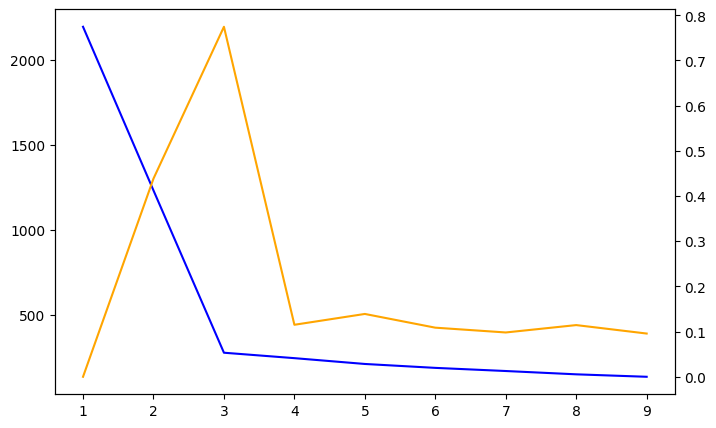

In [13]:
x = df[["x", "y", "z"]].values
wcss = []
k_range = range(1,10)

for k in k_range:
    kmeans = KMeans(n_clusters = k, random_state = 42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

delta = [0]

for k in range(1, len(wcss)):
    delta_k = (wcss[k-1] - wcss[k]) / wcss[k-1]
    delta.append(delta_k) 

fig, ax1 = plt.subplots(figsize=(8,5))

color = "blue"
ax1.plot(k_range, wcss, color=color, label="error")

ax2 = ax1.twinx()
color = "orange"
ax2.plot(k_range, delta, color=color)

plt.show()